In [8]:
from ultralytics import YOLO

model = YOLO("construction-equipment-1/Construction_Project/Experiment1/weights/best.pt")

In [9]:
data_yaml = "construction-equipment-1/data.yaml"

In [10]:
results = model.val(
    data=data_yaml,
    split="val",
    plots=True
)

Ultralytics 8.4.115  Python-3.13.7 torch-2.13.0+cpu CPU (Intel Core i5-5300U 2.30GHz)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.30.2 ms, read: 92.542.4 MB/s, size: 53.1 KB)
val: Scanning C:\Users\Localws\construction-equipment-1\valid\labels.cache... 49 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 49/49 6.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.2s/it 4.9s2.4ss
                   all         49         49      0.522      0.429       0.46      0.228
                     0         49         49      0.522      0.429       0.46      0.228
Speed: 1.4ms preprocess, 74.8ms inference, 0.0ms loss, 2.6ms postprocess per image
Results saved to C:\Users\Localws\runs\detect\val-9


In [11]:
precision = results.box.mp
recall = results.box.mr
map50 = results.box.map50
map50_95 = results.box.map

print("Precision:", precision)
print("Recall:", recall)
print("mAP@50:", map50)
print("mAP@50-95:", map50_95)

Precision: 0.5218858909083377
Recall: 0.42857142857142855
mAP@50: 0.4598851910648724
mAP@50-95: 0.22817312616742105


In [12]:
f1 = 2 * (precision * recall) / (precision + recall)

print("F1 Score:", f1)

F1 Score: 0.47064792333922467


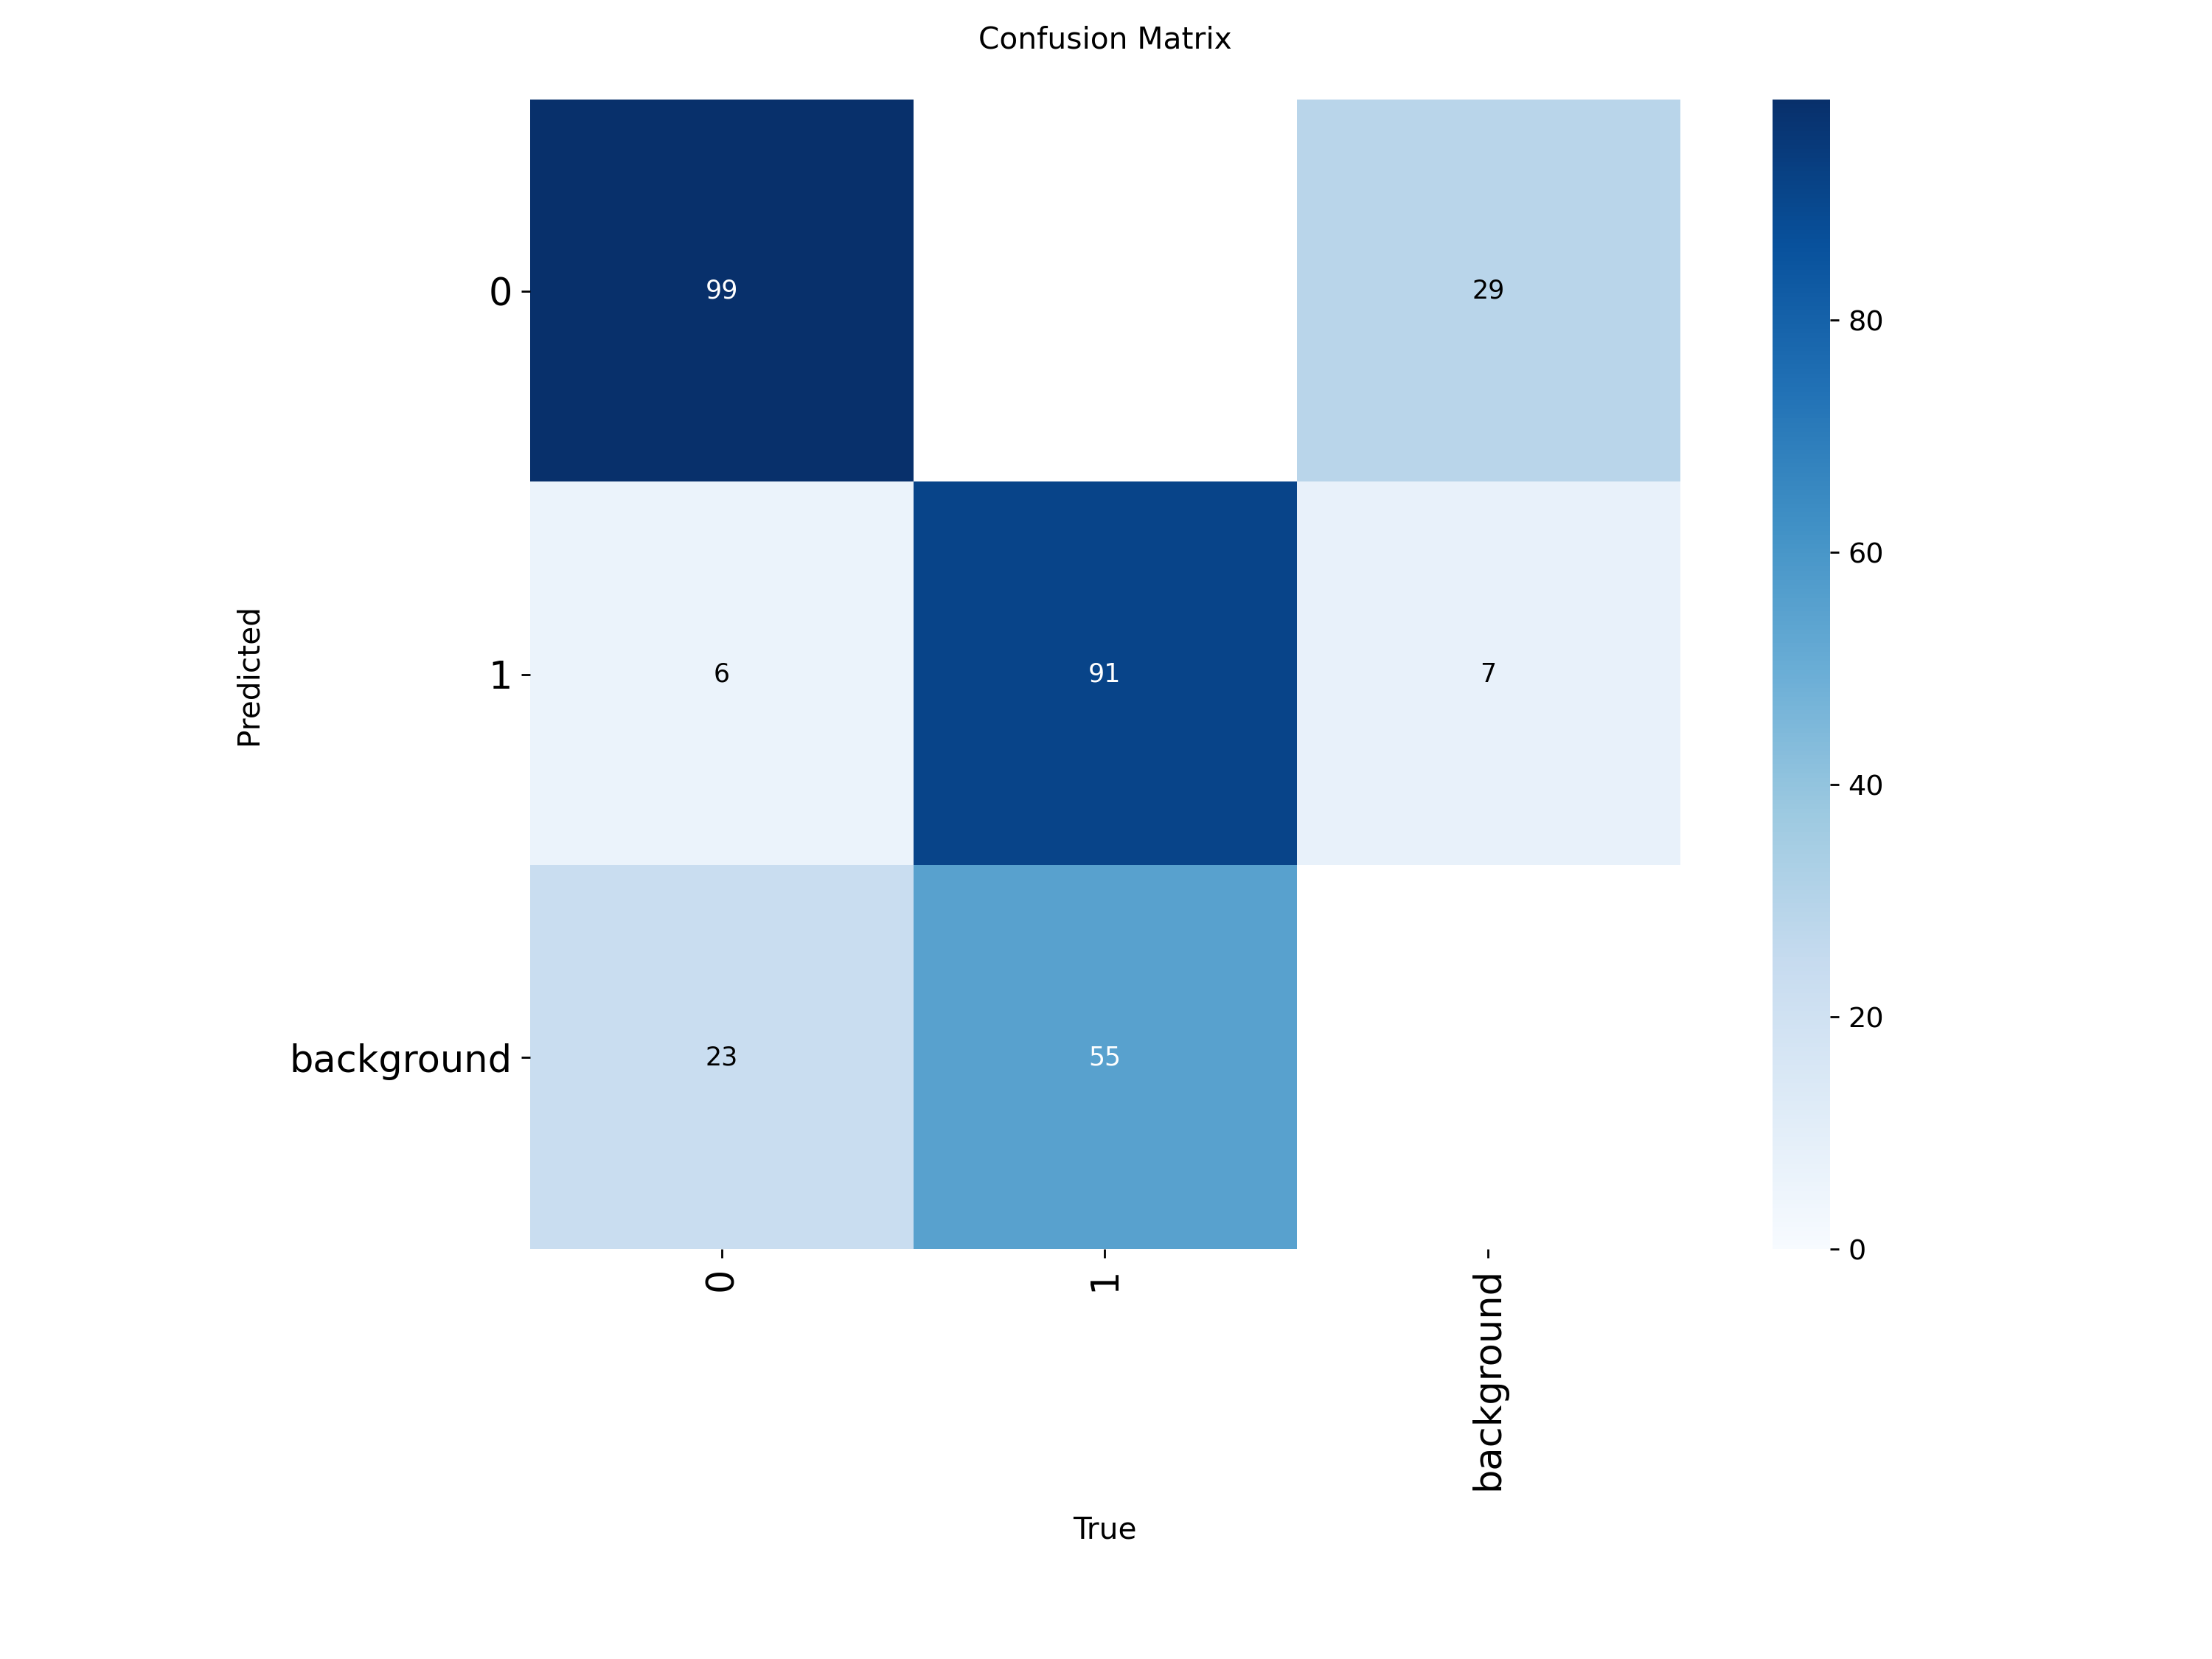

In [13]:
from IPython.display import Image, display

display(Image("runs/detect/val/confusion_matrix.png"))

In [15]:
test_results = model.predict(
    source="construction-equipment-1/test/images",
    save=True,
    conf=0.25
)


image 1/21 C:\Users\Localws\construction-equipment-1\test\images\KakaoTalk_20240402_183303114_01_jpg.rf.72241a56814d05ea1fdbf9d024884c71.jpg: 224x320 1 0, 352.3ms
image 2/21 C:\Users\Localws\construction-equipment-1\test\images\KakaoTalk_20240402_183303114_03_jpg.rf.b82bc5963d2f7bd9ab2bde9029697f85.jpg: 256x320 (no detections), 88.7ms
image 3/21 C:\Users\Localws\construction-equipment-1\test\images\KakaoTalk_20240402_183303114_05_png.rf.4f1e2109082d742355f1a93e2738eab5.jpg: 320x256 1 0, 80.2ms
image 4/21 C:\Users\Localws\construction-equipment-1\test\images\KakaoTalk_20240402_183303114_jpg.rf.72ba716ea8e8a9e2fb6083751b5a65f0.jpg: 256x320 1 0, 60.9ms
image 5/21 C:\Users\Localws\construction-equipment-1\test\images\OIP-1-_jpg.rf.12b8f68fa637ae976abd07544e208e8d.jpg: 224x320 1 0, 67.4ms
image 6/21 C:\Users\Localws\construction-equipment-1\test\images\OIP-10-_jpg.rf.50e07d6f3e54eb6997e9834bc3462ff9.jpg: 192x320 (no detections), 86.6ms
image 7/21 C:\Users\Localws\construction-equipment-1\t

In [18]:
import os

val_path = "construction-equipment-1/valid/images"

val_images = [
    os.path.join(val_path, f)
    for f in os.listdir(val_path)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

val_images = val_images[:9]

print("Validation images selected:", len(val_images))

Validation images selected: 9


In [19]:
val_results = model.predict(
    source=val_images,
    save=True,
    conf=0.25
)


0: 320x320 3 0s, 122.9ms
1: 320x320 3 0s, 122.9ms
2: 320x320 1 0, 122.9ms
3: 320x320 (no detections), 122.9ms
4: 320x320 (no detections), 122.9ms
5: 320x320 (no detections), 122.9ms
6: 320x320 1 0, 122.9ms
7: 320x320 2 0s, 122.9ms
8: 320x320 (no detections), 122.9ms
Speed: 6.0ms preprocess, 122.9ms inference, 0.7ms postprocess per image at shape (1, 3, 320, 320)
Results saved to C:\Users\Localws\runs\detect\predict-5


In [20]:
import pandas as pd

errors = [
    [1, "Helmet detected, construction tractor missed", "Missed object / incorrect detection"],
    [2, "Object missed", "False Negative"],
    [3, "Object missed", "False Negative"],
    [7, "Object missed", "False Negative"],
    [9, "Object missed", "False Negative"],
    [10, "Wrong detection", "False Positive / incorrect detection"],
    [11, "No detection", "False Negative"],
    [12, "No detection", "False Negative"],
    [13, "No detection", "False Negative"],
    [14, "No detection", "False Negative"],
    [15, "No detection", "False Negative"],
    [16, "No detection", "False Negative"],
    [18, "No detection", "False Negative"]
]

error_df = pd.DataFrame(
    errors,
    columns=["Image", "Observed Problem", "Error Type"]
)

error_df

,Image,Observed Problem,Error Type
0,1,"Helmet detected, construction tractor missed",Missed object / incorrect detection
1,2,Object missed,False Negative
2,3,Object missed,False Negative
3,7,Object missed,False Negative
4,9,Object missed,False Negative
5,10,Wrong detection,False Positive / incorrect detection
6,11,No detection,False Negative
7,12,No detection,False Negative
8,13,No detection,False Negative
9,14,No detection,False Negative


In [22]:
import pandas as pd

errors = [
    [1, "Helmet detected but tractor was missed",
     "The model detected the helmet but failed to detect the construction tractor."],

    [2, "No object detected",
     "Construction equipment is visible, but the model did not detect it."],

    [3, "No object detected",
     "Construction equipment is visible, but the model did not detect it."],

    [7, "No object detected",
     "Construction equipment is visible, but the model did not detect it."],

    [9, "No object detected",
     "Construction equipment is visible, but the model did not detect it."],

    [10, "Wrong detection",
     "The model detected an object incorrectly."],

    [11, "No object detected",
     "Construction equipment is visible, but the model did not detect it."],

    [12, "No object detected",
     "Construction equipment is visible, but the model did not detect it."],

    [13, "No object detected",
     "Construction equipment is visible, but the model did not detect it."],

    [14, "No object detected",
     "Construction equipment is visible, but the model did not detect it."],

    [15, "No object detected",
     "Construction equipment is visible, but the model did not detect it."],

    [16, "No object detected",
     "Construction equipment is visible, but the model did not detect it."],

    [18, "No object detected",
     "Construction equipment is visible, but the model did not detect it."]
]

error_df = pd.DataFrame(
    errors,
    columns=["Image", "Observed Error", "Possible Reason"]
)

error_df

,Image,Observed Error,Possible Reason
0,1,Helmet detected but tractor was missed,The model detected the helmet but failed to de...
1,2,No object detected,"Construction equipment is visible, but the mod..."
2,3,No object detected,"Construction equipment is visible, but the mod..."
3,7,No object detected,"Construction equipment is visible, but the mod..."
4,9,No object detected,"Construction equipment is visible, but the mod..."
5,10,Wrong detection,The model detected an object incorrectly.
6,11,No object detected,"Construction equipment is visible, but the mod..."
7,12,No object detected,"Construction equipment is visible, but the mod..."
8,13,No object detected,"Construction equipment is visible, but the mod..."
9,14,No object detected,"Construction equipment is visible, but the mod..."


In [23]:
error_df.to_csv(
    "construction_equipment_error_analysis.csv",
    index=False
)

print("Error analysis report saved successfully.")

Error analysis report saved successfully.
